In [2]:
!pip install --upgrade pip
!pip install numpy
!pip install tensorflow keras

type(images)=<class 'numpy.ndarray'>, type(labels)=<class 'numpy.ndarray'>
images.shape=(1000, 784), labels.shape=(1000,)
weights_0_1.shape=(784, 40), weights_1_2.shape=(40, 10)
 I:0 Train-Err:0.858 Train-Acc:0.462 Test-Err:0.777 Test-Acc:0.565
 I:1 Train-Err:0.675 Train-Acc:0.653 Test-Err:0.590 Test-Acc:0.632
 I:2 Train-Err:0.523 Train-Acc:0.69 Test-Err:0.467 Test-Acc:0.719
 I:3 Train-Err:0.418 Train-Acc:0.764 Test-Err:0.395 Test-Acc:0.771
 I:4 Train-Err:0.351 Train-Acc:0.825 Test-Err:0.364 Test-Acc:0.773
 I:5 Train-Err:0.305 Train-Acc:0.837 Test-Err:0.327 Test-Acc:0.796
 I:6 Train-Err:0.257 Train-Acc:0.861 Test-Err:0.289 Test-Acc:0.814
 I:7 Train-Err:0.243 Train-Acc:0.866 Test-Err:0.261 Test-Acc:0.835
 I:8 Train-Err:0.217 Train-Acc:0.867 Test-Err:0.252 Test-Acc:0.839
 I:9 Train-Err:0.212 Train-Acc:0.874 Test-Err:0.251 Test-Acc:0.832
 I:10 Train-Err:0.219 Train-Acc:0.862 Test-Err:0.258 Test-Acc:0.828
 I:11 Train-Err:0.216 Train-Acc:0.86 Test-Err:0.229 Test-Acc:0.847
 I:12 Train-Err:0.

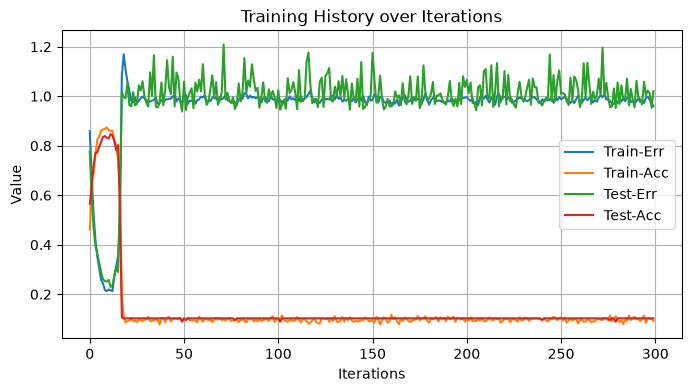

In [ ]:
import sys, numpy as np
from keras.datasets import mnist
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = mnist.load_data()
# 255 is the maximum value of a pixel in an image. Dividing by 255 normalizes the pixel values to be between 0 and 1.
# each deata point is an pixel that has a value between 0 and 255, where 0 is black and 255 is white. By dividing by 255, we scale the pixel values to be between 0 and 1, which is a common practice in machine learning to improve convergence during training.
images, labels = (x_train[0:1000].reshape(1000, 28 * 28) / 255,
                  y_train[0:1000])
print(f"type(images)={type(images)}, type(labels)={type(labels)}")
print(f"images.shape={images.shape}, labels.shape={labels.shape}")

# 0,1,2,3,..,9
# 1000x10 matrix
one_hot_labels = np.zeros((len(labels), 10))
for i, label in enumerate(labels):
    one_hot_labels[i][label] = 1

# Goal Prediction: 0,1,2,3,..,9
labels = one_hot_labels

test_images = x_test.reshape(len(x_test), 28 * 28) / 255
test_labels = np.zeros((len(y_test), 10))
for i, label in enumerate(y_test):
    test_labels[i][label] = 1


def relu(x):
    return (x > 0) * x

def relu2derive(output):
    return output > 0

def tanh(x):
    return np.tanh(x)

def tanh2derive(output):
    return 1 - (output ** 2)

def softmax(x):
    temp = np.exp(x)
    return temp / np.sum(temp, axis=1, keepdims=True)

np.random.seed(1)

alpha, iterations, hidden_size = (0.005, 300, 40)
# 28x28 = 784
pixels_per_image, num_labels = (784, 10)

batch_size = 100

# -0.1 to 0.1
# 784x40 matrix
weights_0_1 = 0.02 * np.random.random((pixels_per_image, hidden_size)) - 0.01
# 40x10 matrix
weights_1_2 = 0.2 * np.random.random((hidden_size , num_labels)) - 0.1

print(f"weights_0_1.shape={weights_0_1.shape}, weights_1_2.shape={weights_1_2.shape}")
# print(f"weights_0_1=\n{weights_0_1}\nweights_1_2=\n{weights_1_2}")

# matlab
train_error = []
train_accuracy = []
test_error = []
test_accuracy = []

for j in range(iterations):
    train_err, train_acc = (0.0, 0)

    length = (int)(len(images) / batch_size)
    for i in range(length):
        batch_start, batch_end = ((i * batch_size), ((i + 1) * batch_size))

        # input layer is 1x784
        layer_0 = images[batch_start:batch_end]
        # hidden layer is 1x40
        ## 1x784 * 783x40 = 1x40
        layer_1 = tanh(np.dot(layer_0, weights_0_1))

        # fill out 0 or 1 randomly for each element in dropou_mask , which has the same shape as layeer_1.
        # 0: disabled (dropout)
        # 1: enabled
        # dropout rate is 0.5 (50%)
        dropout_mask = np.random.randint(2, size=layer_1.shape)
        # retain the same expected value of the output by scaling the enabled neurons by 2 (1 / (1 - dropout_rate) = 1 / (1 - 0.5) = 2)
        layer_1 *= dropout_mask * 2

        # prediction layer is 1x10
        # 1x40 * 40x10 = 1x10
        layer_2 = softmax(np.dot(layer_1, weights_1_2))

        goal_prediction = labels[batch_start:batch_end]
        train_err += np.sum((layer_2 - goal_prediction) ** 2)

        for k in range(batch_size):
            goal_prediction = labels[batch_start + k:batch_start + k + 1]
            train_acc += int(np.argmax(layer_2[k:k+1]) == np.argmax(goal_prediction))

        layer_2_delta = layer_2 - labels[batch_start:batch_end]
        layer_1_delta = layer_2_delta.dot(weights_1_2.T) * tanh2derive(layer_1)
        layer_1_delta *= dropout_mask

        weights_1_2 = weights_1_2 - alpha * layer_1.T.dot(layer_2_delta)
        weights_0_1 = weights_0_1 - alpha * layer_0.T.dot(layer_1_delta)

    # str()[0:5] is used to limit the number of characters displayed for the training error, making the output more concise and easier to read. It effectively truncates the string representation of the training error to the first 5 characters, which typically includes the most significant digits.
    # print("Train-Err=" + str(train_err / float(len(images)))[0:5])
    #train_error.append(train_err / float(len(images)))
    #train_accuracy.append(train_acc / float(len(images)))


#    if( j % 10 == 0 or j == iterations - 1):
    test_err, test_acc = (0.0, 0)

    for i in range(len(test_images)):
        layer_0 = test_images[i:i+1]
        layer_1 = tanh(np.dot(layer_0, weights_0_1))
        layer_2 = softmax(np.dot(layer_1, weights_1_2))

        test_err += np.sum((layer_2 - test_labels[i:i+1]) ** 2)
        test_acc += int(np.argmax(layer_2) == np.argmax(test_labels[i:i+1]))

    sys.stdout.write(
        " I:" + str(j) + \
        " Train-Acc:" + str(train_acc / float(len(images)))[0:5] + \
        " Test-Acc:" + str(test_acc / float(len(test_images)))[0:5]
    )
    sys.stdout.write("\n")

    # matplotlib
    train_error.append(train_err / float(len(images)))
    train_accuracy.append(train_acc / float(len(images)))
    test_error.append(test_err / float(len(test_images)))
    test_accuracy.append(test_acc / float(len(test_images)))

plt.figure(figsize=(8, 4))
plt.plot(train_error, label="Train-Err")
plt.plot(train_accuracy, label="Train-Acc")
plt.plot(test_error, label="Test-Err")
plt.plot(test_accuracy, label="Test-Acc")
plt.xlabel("Iterations")
plt.ylabel("Value")
plt.title("Training History over Iterations")
plt.legend()
plt.grid(True)
plt.show()

